# Nhiệm vụ 9 — Độ ổn định thời gian PCA + K-Means

Đọc ba CSV phẳng đã được nhiệm vụ 6 tái lập từ assignments và profiles cùng nhãn aligned:
`temporal_stability.csv` (14×10), `transition_matrices.csv` (56×6), `centroid_drift.csv` (224×7)
ở `M2/artifacts/m2-evaluation-pca-kmeans/`.
Chỉ so sánh cổ phiếu chung giữa hai tháng; entry/exit tách riêng.
Không fit lại, không đọc holdout; phân cụm độc lập rồi đo temporal diagnostics **không phải Dynamic Clustering**.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Tìm root bằng file config, không phụ thuộc tên thư mục hoặc máy cá nhân.
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / 'configs/experiments/m2_task6_pca.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Chạy notebook từ repository hoặc M2/notebooks.')
sys.path.insert(0, str(ROOT / 'src'))
from delta_t1.experiments.protocol import validate_protocol
CONFIG = json.loads((ROOT / 'configs/experiments/m2_task6_pca.json').read_text(encoding='utf-8'))
validate_protocol(CONFIG)
FEATURES = CONFIG['clustering']['features']
DEV_DATES = CONFIG['development_snapshots']
K = CONFIG['clustering']['k']
TASK_DIR = ROOT / 'M2/artifacts/m2-task6-pca-kmeans-v1'
EVAL_DIR = ROOT / 'M2/artifacts/m2-evaluation-pca-kmeans'
REPORT_DIR = ROOT / 'M2/reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
print('Root:', ROOT)
print('Development:', DEV_DATES[0], '→', DEV_DATES[-1], '| Global K:', K)

def publish_csv(path, frame):
    content = frame.to_csv(index=False, lineterminator='\n').encode('utf-8')
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != content:
        raise RuntimeError(f'CSV khác nội dung đã tồn tại: {path}; cần version mới.')
    if not path.exists():
        path.write_bytes(content)

def table_md(frame):
    def clean(value):
        return str(value).replace('|', '\\|').replace('\n', ' ')
    columns = frame.columns.tolist()
    lines = ['| ' + ' | '.join(map(clean, columns)) + ' |',
             '| ' + ' | '.join(['---'] * len(columns)) + ' |']
    for row in frame.itertuples(index=False, name=None):
        lines.append('| ' + ' | '.join(map(clean, row)) + ' |')
    return '\n'.join(lines)

Root: C:\Users\HOME\Desktop\M2\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment
Development: 2023-11-30 → 2025-01-24 | Global K: 2


## 9.1–9.8 — Kiểm tra schemas, liên tục theo tháng, drift và transitions

In [2]:
# Fail-closed: chỉ đọc bộ v2 hoàn tất, có checksum và cùng config.
manifest = json.loads((TASK_DIR / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
assert manifest['config'] == CONFIG, 'Config thay đổi: cần run/version mới.'
for rel, expected in manifest['artifacts'].items():
    path = ROOT / rel
    assert hashlib.sha256(path.read_bytes()).hexdigest() == expected, f'Checksum mismatch: {rel}'

df_temp = pd.read_csv(EVAL_DIR/'temporal_stability.csv')
df_trans = pd.read_csv(EVAL_DIR/'transition_matrices.csv')
df_drift = pd.read_csv(EVAL_DIR/'centroid_drift.csv')
assert df_temp.columns.tolist() == ['from_date','to_date','n_common','ari','nmi',
    'persistence_probability','migration_rate','entered_count','exited_count','status']
assert df_trans.columns.tolist() == ['from_date','to_date','from_cluster','to_cluster','count','rate']
assert df_drift.columns.tolist() == ['from_date','to_date','aligned_cluster_id','feature','value_from','value_to','delta']
assert df_temp.shape == (14,10) and df_trans.shape == (56,6) and df_drift.shape == (224,7)
EXPECTED_PAIRS = list(zip(DEV_DATES[:-1], DEV_DATES[1:]))
assert list(zip(df_temp.from_date,df_temp.to_date)) == EXPECTED_PAIRS
for previous, current in EXPECTED_PAIRS:
    assert pd.Period(current, freq='M').ordinal - pd.Period(previous, freq='M').ordinal == 1
for frame in [df_temp,df_trans,df_drift]:
    assert set(zip(frame.from_date,frame.to_date)) == set(EXPECTED_PAIRS)
    assert frame.from_date.lt(DEV_DATES[-1]).all() and frame.to_date.le(DEV_DATES[-1]).all()
assert not df_trans.duplicated(['from_date','to_date','from_cluster','to_cluster']).any()
assert not df_drift.duplicated(['from_date','to_date','aligned_cluster_id','feature']).any()
assert df_temp.status.eq('OK').all() and df_temp.n_common.gt(0).all()
assert df_temp[['entered_count','exited_count']].ge(0).all().all()
assert np.isfinite(df_temp[['ari','nmi','persistence_probability','migration_rate']].to_numpy(float)).all()
assert df_temp.ari.between(-1,1).all() and df_temp.nmi.between(0,1).all()
assert df_temp[['persistence_probability','migration_rate']].ge(0).all().all()
assert df_temp[['persistence_probability','migration_rate']].le(1).all().all()
assert np.allclose(df_temp.persistence_probability + df_temp.migration_rate, 1)
assert np.isfinite(df_drift[['value_from','value_to','delta']].to_numpy(float)).all()
assert np.allclose(df_drift.delta, df_drift.value_to-df_drift.value_from)
assert not df_drift.value_from.eq(0).all(), 'Tâm tháng trước không được là placeholder zero.'
for row in df_temp.itertuples():
    tr = df_trans[df_trans.from_date.eq(row.from_date)&df_trans.to_date.eq(row.to_date)]
    assert set(zip(tr.from_cluster,tr.to_cluster)) == {(0,0),(0,1),(1,0),(1,1)}
    assert tr['count'].ge(0).all() and tr['count'].sum() == row.n_common
    assert np.isclose(tr.loc[tr.from_cluster.eq(tr.to_cluster),'count'].sum()/row.n_common, row.persistence_probability)
    for cluster in range(K):
        sub = tr[tr.from_cluster.eq(cluster)]
        denominator = sub['count'].sum()
        if denominator:
            assert np.allclose(sub.rate, sub['count']/denominator)
        else:
            assert sub.rate.isna().all()
        dr = df_drift[df_drift.from_date.eq(row.from_date)&df_drift.to_date.eq(row.to_date)
            &df_drift.aligned_cluster_id.eq(cluster)]
        assert set(dr.feature) == set(FEATURES) and len(dr) == 8
print('PASS GAP RESET: đúng 15 tháng liên tục/14 cặp; không có liên kết vượt 24/01/2025 vào gap 02/2025–01/2026.')
print('Không mở holdout; phép kiểm này xác minh chain của bộ development hiện tại.')

PASS GAP RESET: đúng 15 tháng liên tục/14 cặp; không có liên kết vượt 24/01/2025 vào gap 02/2025–01/2026.
Không mở holdout; phép kiểm này xác minh chain của bộ development hiện tại.


## Bảng 1 — ARI, NMI, Persistence và Migration: 4 dòng × 6 cột

In [3]:
metrics = [('ARI','ari',1),('NMI','nmi',1),('Persistence (%)','persistence_probability',100),('Migration (%)','migration_rate',100)]
table1 = pd.DataFrame([{
    'Chỉ số (Metric)': label, 'Số cặp quan sát': len(df_temp),
    'Trung bình (Mean)': df_temp[column].mean()*factor,
    'Trung vị (Median)': df_temp[column].median()*factor,
    'Nhỏ nhất (Min)': df_temp[column].min()*factor,
    'Lớn nhất (Max)': df_temp[column].max()*factor} for label,column,factor in metrics])
assert table1.shape == (4,6)
display(table1.round(4))

,Chỉ số (Metric),Số cặp quan sát,Trung bình (Mean),Trung vị (Median),Nhỏ nhất (Min),Lớn nhất (Max)
0,ARI,14,0.7896,0.7983,0.5758,0.9608
1,NMI,14,0.6690,0.6613,0.4387,0.9113
2,Persistence (%),14,98.2756,98.5618,95.5285,99.4863
3,Migration (%),14,1.7244,1.4382,0.5137,4.4715


## Bảng 2 — Chuyển cụm tích lũy theo aligned IDs: 4 dòng × 5 cột

In [4]:
counts = df_trans.groupby(['from_cluster','to_cluster'])['count'].sum().unstack().reindex(index=[0,1],columns=[0,1],fill_value=0)
transition_rates = counts.div(counts.sum(axis=1),axis=0)*100
table2_rows = []
for source,destination in [(0,0),(0,1),(1,1),(1,0)]:
    denominator = int(counts.loc[source].sum())
    table2_rows.append({'Từ Cụm (From)':f'Cụm {source}',
        'Sang Cụm (To)':f'Cụm {destination} ('+('Giữ nguyên' if source==destination else 'Chuyển cụm')+')',
        'Tổng số lượt (Count)':int(counts.loc[source,destination]),
        'Tổng số cơ sở (Denominator)':denominator,
        'Tỷ lệ xác suất (Rate %)':transition_rates.loc[source,destination]})
table2 = pd.DataFrame(table2_rows)
assert table2.shape == (4,5)
display(table2.round(4))

,Từ Cụm (From),Sang Cụm (To),Tổng số lượt (Count),Tổng số cơ sở (Denominator),Tỷ lệ xác suất (Rate %)
0,Cụm 0,Cụm 0 (Giữ nguyên),161,199,80.9045
1,Cụm 0,Cụm 1 (Chuyển cụm),38,199,19.0955
2,Cụm 1,Cụm 1 (Giữ nguyên),4574,4606,99.3053
3,Cụm 1,Cụm 0 (Chuyển cụm),32,4606,0.6947


## Bảng 3 — Mean |Δ| trên 8 feature gốc: 8 dòng × 3 cột

In [5]:
drift_agg = df_drift.assign(abs_delta=df_drift.delta.abs()).groupby(['feature','aligned_cluster_id']).abs_delta.mean().unstack()
FEATURE_ORDER = ['liquidity_21','beta_126','vol_63','mdd_126','mom_21','mom_63','mom_126','mom_252']
table3 = pd.DataFrame([{'Đặc trưng': 'liquidity_21 (tỷ VND)' if f=='liquidity_21' else f,
    'Độ lệch tuyệt đối Cụm 0 (Mean |Delta|)':drift_agg.loc[f,0]/(1e9 if f=='liquidity_21' else 1),
    'Độ lệch tuyệt đối Cụm 1 (Mean |Delta|)':drift_agg.loc[f,1]/(1e9 if f=='liquidity_21' else 1)} for f in FEATURE_ORDER])
assert table3.shape == (8,3)
display(table3.round(4))
display(Markdown('Drift giữ đơn vị gốc theo feature; không cộng các feature khác đơn vị thành một số.'))

,Đặc trưng,Độ lệch tuyệt đối Cụm 0 (Mean |Delta|),Độ lệch tuyệt đối Cụm 1 (Mean |Delta|)
0,liquidity_21 (tỷ VND),94.1176,3.9778
1,beta_126,0.0562,0.0493
2,vol_63,0.0283,0.0332
3,mdd_126,0.0233,0.0153
4,mom_21,0.0587,0.0412
5,mom_63,0.0616,0.0347
6,mom_126,0.0697,0.0416
7,mom_252,0.1075,0.0527


Drift giữ đơn vị gốc theo feature; không cộng các feature khác đơn vị thành một số.

## Bảng 4 — Entry/Exit: 14 dòng × 5 cột

Tỷ lệ luân chuyển universe=(Entry+Exit)/n_common×100.
Mẫu số được ghi rõ để so sánh; tỷ lệ có thể vượt 100% khi universe mở rộng mạnh.
Đây là biến động membership, **không phải portfolio turnover**; migration chỉ đo trên giao universe.

In [6]:
universe_ratio = (df_temp.entered_count+df_temp.exited_count)/df_temp.n_common*100
table4 = pd.DataFrame({'Cặp Snapshot (From -> To)': [f'{a[:7]} → {b[:7]}' for a,b in EXPECTED_PAIRS],
    'Số mã chung (n_common)':df_temp.n_common, 'Số mã mới (Entry)':df_temp.entered_count,
    'Số mã rớt (Exit)':df_temp.exited_count,'Tỷ lệ luân chuyển (%)':universe_ratio})
assert table4.shape == (14,5)
display(table4.round(4))

,Cặp Snapshot (From -> To),Số mã chung (n_common),Số mã mới (Entry),Số mã rớt (Exit),Tỷ lệ luân chuyển (%)
0,2023-11 → 2023-12,140,55,2,40.7143
1,2023-12 → 2024-01,191,5,4,4.7120
2,2024-01 → 2024-02,196,0,0,0.0000
3,2024-02 → 2024-03,196,1,0,0.5102
4,2024-03 → 2024-04,197,17,0,8.6294
5,2024-04 → 2024-05,210,11,4,7.1429
6,2024-05 → 2024-06,221,19,0,8.5973
7,2024-06 → 2024-07,238,9,2,4.6218
8,2024-07 → 2024-08,246,349,1,142.2764
9,2024-08 → 2024-09,591,15,4,3.2149


## 9.9 — Hai biểu đồ chuẩn

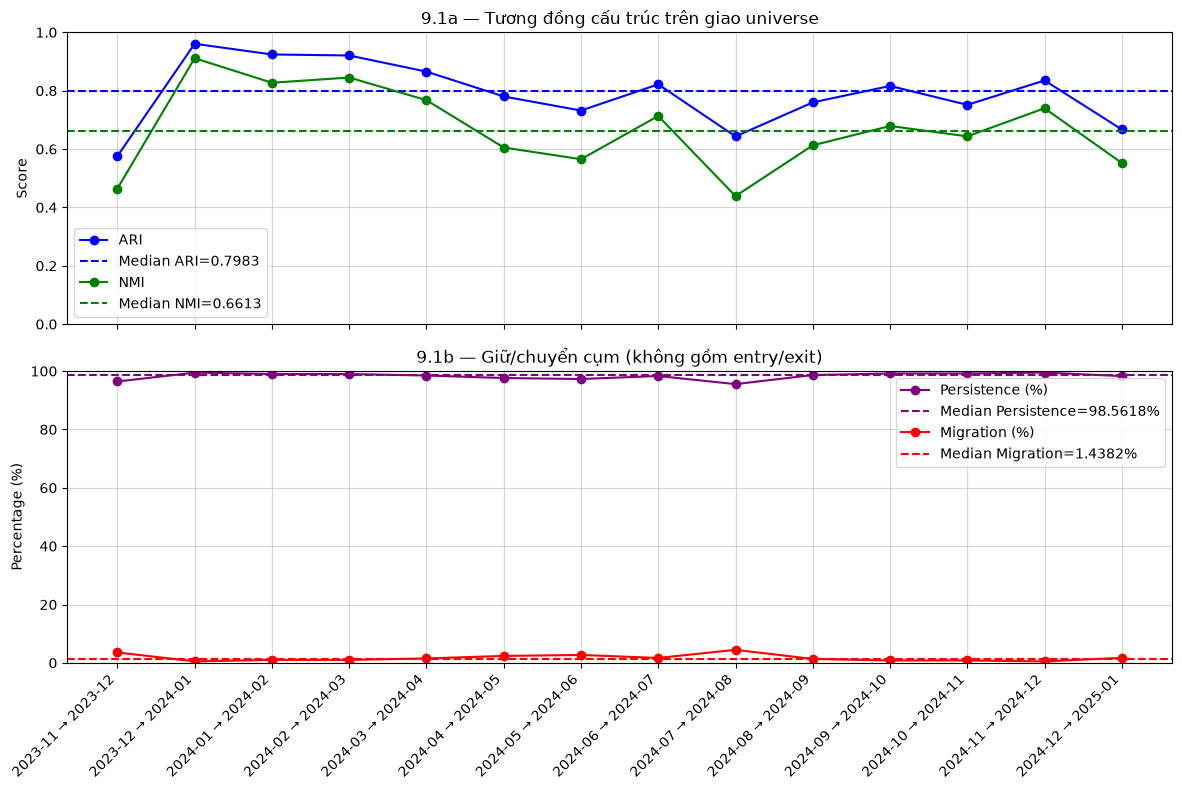

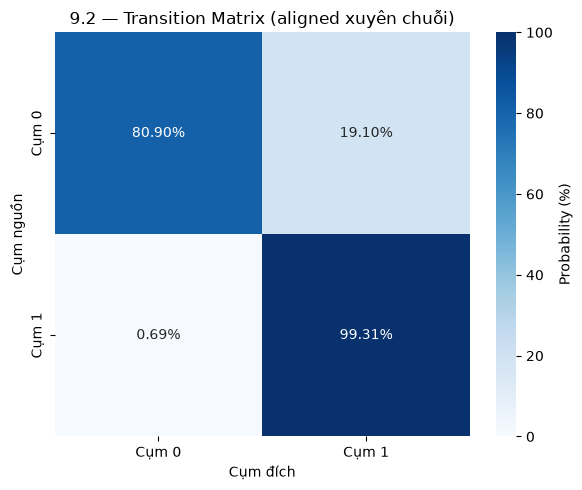

In [7]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(12,8),sharex=True)
x = np.arange(14)
for metric,color in [('ari','blue'),('nmi','green')]:
    ax1.plot(x,df_temp[metric],marker='o',label=metric.upper(),color=color)
    ax1.axhline(df_temp[metric].median(),color=color,linestyle='--',
        label=f'Median {metric.upper()}={df_temp[metric].median():.4f}')
ax1.set(ylim=(0,1),ylabel='Score',title='9.1a — Tương đồng cấu trúc trên giao universe')
ax1.legend(); ax1.grid(alpha=.5)
for metric,color,label in [('persistence_probability','purple','Persistence'),('migration_rate','red','Migration')]:
    ax2.plot(x,df_temp[metric]*100,marker='o',color=color,label=label+' (%)')
    ax2.axhline(df_temp[metric].median()*100,color=color,linestyle='--',
        label=f'Median {label}={df_temp[metric].median()*100:.4f}%')
ax2.set(ylim=(0,100),ylabel='Percentage (%)',title='9.1b — Giữ/chuyển cụm (không gồm entry/exit)')
ax2.set_xticks(x,table4.iloc[:,0],rotation=45,ha='right')
ax2.legend(); ax2.grid(alpha=.5)
fig.tight_layout()
fig.savefig(EVAL_DIR/'temporal_trends.png',dpi=160,bbox_inches='tight')
plt.show(); plt.close(fig)

import seaborn as sns
fig,ax = plt.subplots(figsize=(6,5))
annotations = transition_rates.map(lambda value:f'{value:.2f}%')
sns.heatmap(transition_rates,annot=annotations,fmt='',cmap='Blues',vmin=0,vmax=100,
    xticklabels=['Cụm 0','Cụm 1'],yticklabels=['Cụm 0','Cụm 1'],ax=ax,cbar_kws={'label':'Probability (%)'})
ax.set(title='9.2 — Transition Matrix (aligned xuyên chuỗi)',xlabel='Cụm đích',ylabel='Cụm nguồn')
fig.tight_layout()
fig.savefig(EVAL_DIR/'transition_heatmap.png',dpi=160,bbox_inches='tight')
plt.show(); plt.close(fig)

## 9.10 — Biện luận và giới hạn thực chứng

In [8]:
ari,nmi = df_temp.ari.median(),df_temp.nmi.median()
persistence,migration = df_temp.persistence_probability.median()*100,df_temp.migration_rate.median()*100
worst = df_temp.loc[df_temp.ari.idxmin()]
maximum_universe = df_temp.loc[universe_ratio.idxmax()]
conclusion = f"""# Báo cáo Nhiệm vụ 9 — Temporal Stability PCA + K-Means

Nguồn: ba CSV phẳng ở `m2-evaluation-pca-kmeans`; 14 cặp development liên tiếp.
Temporal inputs được dựng từ cùng nhãn aligned của task 6 và kiểm tra checksum.

## A — Phán quyết độ ổn định
Median ARI={ari:.6f}, NMI={nmi:.6f}; ARI >0,70 ở {int(df_temp.ari.gt(.70).sum())}/14 cặp.
ARI thấp nhất {worst.ari:.6f} tại {worst.from_date} → {worst.to_date};
có {int(df_temp.ari.lt(.5).sum())} cặp ARI <0,50. Phân hoạch khá ổn định, không bất biến.
Không có dữ liệu VN-Index trong notebook nên không khẳng định cú sốc thị trường là nguyên nhân.

## B — Persistence/Migration và tác động tiềm tàng
Median Persistence={persistence:.4f}%, Migration={migration:.4f}% trên giao universe.
Tỷ lệ giữ cụm gộp theo lượt: C0={transition_rates.loc[0,0]:.4f}%
(cơ sở {counts.loc[0].sum()} lượt), C1={transition_rates.loc[1,1]:.4f}%
(cơ sở {counts.loc[1].sum()} lượt); tổng thể bị chi phối bởi nhóm lớn.
Migration thấp không đồng nghĩa chi phí giao dịch thấp: Entry+Exit lớn nhất so với n_common
là {universe_ratio.max():.4f}% tại {maximum_universe.from_date} → {maximum_universe.to_date}.
Chi phí/turnover danh mục còn phụ thuộc weights, size vốn và quy tắc tái cân bằng ở M3.
Drift dùng tâm gốc thật, theo từng feature; không gộp khác đơn vị.

## C — Bàn giao và giới hạn
Đủ bốn bảng và hai biểu đồ; đúng 14 cặp, không nối qua gap 02/2025–01/2026.
Kết quả mô tả development-only, không chứng minh PCA bền hơn phương án khác,
không phải Dynamic Clustering, không dùng để chọn mã hoặc suy diễn lợi nhuận.
"""
display(Markdown(conclusion))
report = conclusion
for number,frame in enumerate([table1,table2,table3,table4],1):
    report += f'\n## Bảng {number}\n' + table_md(frame.round(4))
report += '\n![Temporal](../artifacts/m2-evaluation-pca-kmeans/temporal_trends.png)\n![Transitions](../artifacts/m2-evaluation-pca-kmeans/transition_heatmap.png)\n'
(REPORT_DIR/'Bao_cao_M2_Nhiem_vu_9_Do_on_dinh_thoi_gian_PCA_KMeans.md').write_text(report,encoding='utf-8')
assert (EVAL_DIR/'temporal_trends.png').stat().st_size>0 and (EVAL_DIR/'transition_heatmap.png').stat().st_size>0

# Báo cáo Nhiệm vụ 9 — Temporal Stability PCA + K-Means

Nguồn: ba CSV phẳng ở `m2-evaluation-pca-kmeans`; 14 cặp development liên tiếp.
Temporal inputs được dựng từ cùng nhãn aligned của task 6 và kiểm tra checksum.

## A — Phán quyết độ ổn định
Median ARI=0.798251, NMI=0.661313; ARI >0,70 ở 11/14 cặp.
ARI thấp nhất 0.575783 tại 2023-11-30 → 2023-12-29;
có 0 cặp ARI <0,50. Phân hoạch khá ổn định, không bất biến.
Không có dữ liệu VN-Index trong notebook nên không khẳng định cú sốc thị trường là nguyên nhân.

## B — Persistence/Migration và tác động tiềm tàng
Median Persistence=98.5618%, Migration=1.4382% trên giao universe.
Tỷ lệ giữ cụm gộp theo lượt: C0=80.9045%
(cơ sở 199 lượt), C1=99.3053%
(cơ sở 4606 lượt); tổng thể bị chi phối bởi nhóm lớn.
Migration thấp không đồng nghĩa chi phí giao dịch thấp: Entry+Exit lớn nhất so với n_common
là 142.2764% tại 2024-07-31 → 2024-08-30.
Chi phí/turnover danh mục còn phụ thuộc weights, size vốn và quy tắc tái cân bằng ở M3.
Drift dùng tâm gốc thật, theo từng feature; không gộp khác đơn vị.

## C — Bàn giao và giới hạn
Đủ bốn bảng và hai biểu đồ; đúng 14 cặp, không nối qua gap 02/2025–01/2026.
Kết quả mô tả development-only, không chứng minh PCA bền hơn phương án khác,
không phải Dynamic Clustering, không dùng để chọn mã hoặc suy diễn lợi nhuận.


## Kết luận A/B/C từ số liệu đã chạy

## A — Phán quyết độ ổn định
Median ARI=0.798251, NMI=0.661313; ARI >0,70 ở 11/14 cặp.
ARI thấp nhất 0.575783 tại 2023-11-30 → 2023-12-29;
có 0 cặp ARI <0,50. Phân hoạch khá ổn định, không bất biến.
Không có dữ liệu VN-Index trong notebook nên không khẳng định cú sốc thị trường là nguyên nhân.

## B — Persistence/Migration và tác động tiềm tàng
Median Persistence=98.5618%, Migration=1.4382% trên giao universe.
Tỷ lệ giữ cụm gộp theo lượt: C0=80.9045%
(cơ sở 199 lượt), C1=99.3053%
(cơ sở 4606 lượt); tổng thể bị chi phối bởi nhóm lớn.
Migration thấp không đồng nghĩa chi phí giao dịch thấp: Entry+Exit lớn nhất so với n_common
là 142.2764% tại 2024-07-31 → 2024-08-30.
Chi phí/turnover danh mục còn phụ thuộc weights, size vốn và quy tắc tái cân bằng ở M3.
Drift dùng tâm gốc thật, theo từng feature; không gộp khác đơn vị.

## C — Bàn giao và giới hạn
Đủ bốn bảng và hai biểu đồ; đúng 14 cặp, không nối qua gap 02/2025–01/2026.
Kết quả mô tả development-only, không chứng minh PCA bền hơn phương án khác,
không phải Dynamic Clustering, không dùng để chọn mã hoặc suy diễn lợi nhuận.